etapa 1 — album reducido (n=100, s=7, r=10 000)
media sobres necesarios        : 72.2456
desv. estandar sobres          : 17.4715
media estampas repetidas       : 405.7192
desv. estandar repetidas       : 122.3006
p(sobres > 30)                 : 1.0000

minimo teorico (n/s = 100/7)   : 15
h_100 (aprox ln+γ)             : 5.182370
h_100 (suma exacta)            : 5.187378
e[t] teorico (aprox)           : 74.0339
e[t] teorico (exacto)          : 74.1054
e[repetidas] estimado sim.     : 405.7192
e[repetidas] teorico aprox.    : 405.7192


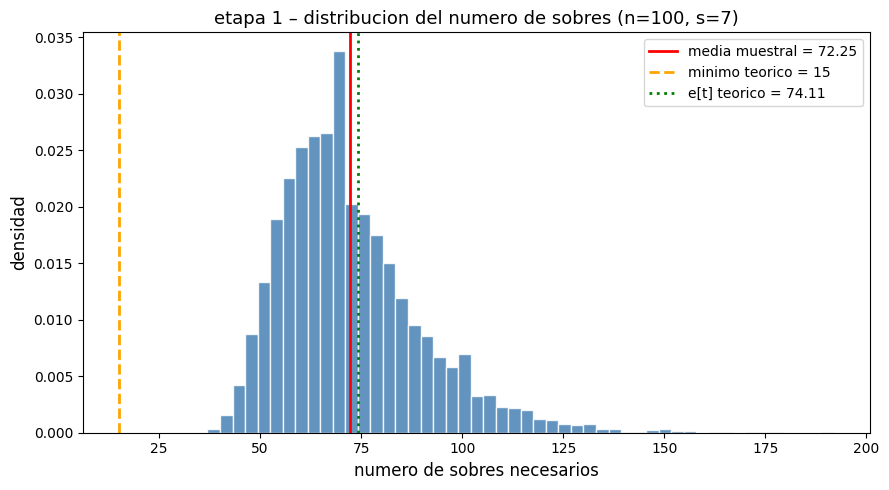


etapa 2 — probabilidad de exito vs. sobres comprados
    m   p(completar | m sobres)
--------------------------------
   20                    0.0000
   25                    0.0000
   30                    0.0000
   35                    0.0000
   40                    0.0019
   45                    0.0143
   50                    0.0571
   60                    0.2723
   70                    0.5340
   80                    0.7393

primero con p ≥ 50%: m = 70  (p = 0.5340)

cota superior p(falta ≥1 cromo) con m=50: 3.0197
p(fracaso | m=50) simulada              : 0.9429
p(exito   | m=50) simulada              : 0.0571


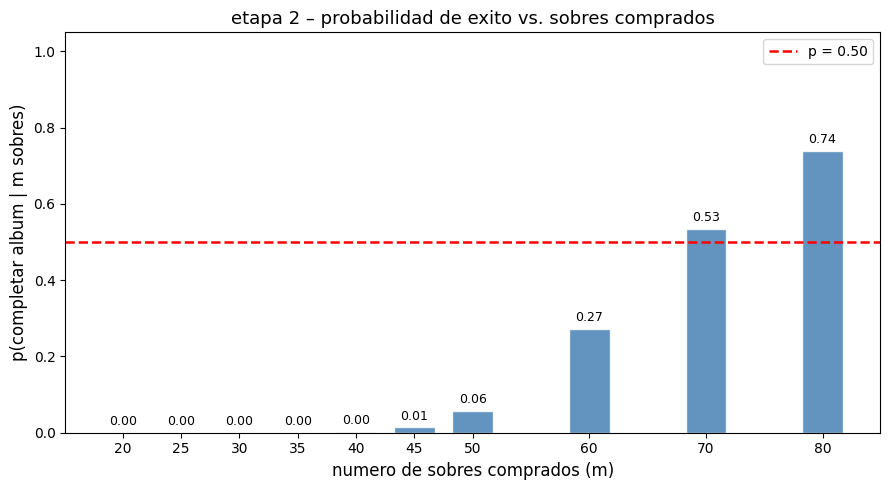

In [ ]:
# Antony Saz 24710
# Mariana castaneda 24481
# laboratorio 7 de prob
#se uso de ayuda chatgpt para realiar ciertas partes del codigo

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(2026)

# etapa 1: simulacion basica con album reducido

n = 100
s = 7
r = 10000

sobres_list = []
repetidas_list = []

for _ in range(r):
    album = np.zeros(n, dtype=bool)
    sobres = 0
    repetidas = 0
    while not album.all():
        nuevas = np.random.choice(n, s, replace=False)
        sobres += 1
        for e in nuevas:
            if album[e]:
                repetidas += 1
            else:
                album[e] = True
    sobres_list.append(sobres)
    repetidas_list.append(repetidas)

sobres_arr = np.array(sobres_list)
rep_arr    = np.array(repetidas_list)

media_sobres = sobres_arr.mean()
std_sobres   = sobres_arr.std()
media_rep    = rep_arr.mean()
std_rep      = rep_arr.std()

# minimo teorico
min_teorico = int(np.ceil(n / s))

# teoria del coleccionista
h100_aprox = np.log(100) + 0.5772
h100_exact = sum(1/k for k in range(1, 101))
e_teorico_aprox = (n / s) * h100_aprox
e_teorico_exact = (n / s) * h100_exact

# repetidas teoricas esperadas
e_rep_teorico = media_sobres * s - n

prob_mas30 = np.mean(sobres_arr > 30)

print("=" * 55)
print("etapa 1 — album reducido (n=100, s=7, r=10 000)")
print("=" * 55)
print(f"media sobres necesarios        : {media_sobres:.4f}")
print(f"desv. estandar sobres          : {std_sobres:.4f}")
print(f"media estampas repetidas       : {media_rep:.4f}")
print(f"desv. estandar repetidas       : {std_rep:.4f}")
print(f"p(sobres > 30)                 : {prob_mas30:.4f}")
print()
print(f"minimo teorico (n/s = 100/7)   : {min_teorico}")
print(f"h_100 (aprox ln+γ)             : {h100_aprox:.6f}")
print(f"h_100 (suma exacta)            : {h100_exact:.6f}")
print(f"e[t] teorico (aprox)           : {e_teorico_aprox:.4f}")
print(f"e[t] teorico (exacto)          : {e_teorico_exact:.4f}")
print(f"e[repetidas] estimado sim.     : {media_rep:.4f}")
print(f"e[repetidas] teorico aprox.    : {e_rep_teorico:.4f}")

#  histograma etapa 1
fig1, ax1 = plt.subplots(figsize=(9, 5))
ax1.hist(sobres_arr, bins=50, color='steelblue', edgecolor='white', alpha=0.85, density=True)
ax1.axvline(media_sobres, color='red',    lw=2, label=f'media muestral = {media_sobres:.2f}')
ax1.axvline(min_teorico,  color='orange', lw=2, linestyle='--', label=f'minimo teorico = {min_teorico}')
ax1.axvline(e_teorico_exact, color='green', lw=2, linestyle=':', label=f'e[t] teorico = {e_teorico_exact:.2f}')
ax1.set_xlabel('numero de sobres necesarios', fontsize=12)
ax1.set_ylabel('densidad', fontsize=12)
ax1.set_title('etapa 1 – distribucion del numero de sobres (n=100, s=7)', fontsize=13)
ax1.legend()
plt.tight_layout()
plt.savefig('etapa1_histograma.png', dpi=150)
plt.show()
plt.close()



# etapa 2 probabilidad de exito en funcion del numero de sobres

np.random.seed(2026)

m_valores = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]
prob_exito = []

for m in m_valores:
    exitos = 0
    for _ in range(r):
        album = np.zeros(n, dtype=bool)
        for _ in range(m):
            nuevas = np.random.choice(n, s, replace=False)
            album[nuevas] = True
        if album.all():
            exitos += 1
    p = exitos / r
    prob_exito.append(p)

print("\n" + "=" * 55)
print("etapa 2 — probabilidad de exito vs. sobres comprados")
print("=" * 55)
print(f"{'m':>5}  {'p(completar | m sobres)':>24}")
print("-" * 32)
for m, p in zip(m_valores, prob_exito):
    print(f"{m:>5}  {p:>24.4f}")

# primero que supera 50 % y 90 %
for m, p in zip(m_valores, prob_exito):
    if p >= 0.50:
        print(f"\nprimero con p ≥ 50%: m = {m}  (p = {p:.4f})")
        break
for m, p in zip(m_valores, prob_exito):
    if p >= 0.90:
        print(f"primero con p ≥ 90%: m = {m}  (p = {p:.4f})")
        break

# cota superior por union de eventos para m=50
m_cota = 50
cota_sup = n * np.exp(-m_cota * s / n)
p_sim_50 = prob_exito[m_valores.index(50)]
print(f"\ncota superior p(falta ≥1 cromo) con m=50: {cota_sup:.4f}")
print(f"p(fracaso | m=50) simulada              : {1 - p_sim_50:.4f}")
print(f"p(exito   | m=50) simulada              : {p_sim_50:.4f}")

# grafica etapa 2
fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.bar(m_valores, prob_exito, width=3.5, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axhline(0.5, color='red', lw=1.8, linestyle='--', label='p = 0.50')
ax2.set_xlabel('numero de sobres comprados (m)', fontsize=12)
ax2.set_ylabel('p(completar album | m sobres)', fontsize=12)
ax2.set_title('etapa 2 – probabilidad de exito vs. sobres comprados', fontsize=13)
ax2.set_xticks(m_valores)
ax2.set_ylim(0, 1.05)
for m, p in zip(m_valores, prob_exito):
    ax2.text(m, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)
ax2.legend()
plt.tight_layout()
plt.savefig('etapa2_probabilidad.png', dpi=150)
plt.show()
plt.close()
